In [113]:
import pandas as pd

df = pd.read_csv("/Users/hayaalbuhaisi/Desktop/cardekho.csv")


In [115]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [117]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [119]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [121]:
df['max_power'] = df['max_power'].str.replace(' bhp', '')

df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7912 non-null   float64
 11  seats               7907 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 762.1 KB


In [129]:
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(
    df['mileage(km/ltr/kg)'].median()
)

df['engine'] = df['engine'].fillna(
    df['engine'].median()
)

df['max_power'] = df['max_power'].fillna(
    df['max_power'].median()
)

df['seats'] = df['seats'].fillna(
    df['seats'].median()
)

In [131]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [133]:
df.drop('name', axis=1, inplace=True)

In [135]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='str')

In [137]:
df = pd.get_dummies(
    df,
    columns=[
        'fuel',
        'seller_type',
        'transmission',
        'owner'
    ],
    drop_first=True
)

In [139]:
df.head()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


In [143]:
X = df.drop('selling_price', axis=1)

y = df['selling_price']

In [145]:
X.shape, y.shape

((8128, 16), (8128,))

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((6502, 16), (1626, 16))

In [151]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [153]:
X_train_scaled[:5]

array([[ 1.27937674e+00, -1.15659237e+00,  1.15704298e+00,
        -5.13715896e-01, -2.12283147e-01, -4.26905059e-01,
        -1.09492017e+00, -6.92141910e-02,  1.12144500e+00,
         4.41589084e-01, -1.71607163e-01, -2.61053708e+00,
        -1.48883599e-01, -5.91204384e-01, -2.48107643e-02,
        -2.67107068e-01],
       [-1.96059154e-01,  1.70496210e-01, -1.32144605e-03,
        -5.15723152e-01, -1.27802206e-01, -4.26905059e-01,
        -1.09492017e+00, -6.92141910e-02,  1.12144500e+00,
         4.41589084e-01, -1.71607163e-01,  3.83062937e-01,
        -1.48883599e-01,  1.69146242e+00, -2.48107643e-02,
        -2.67107068e-01],
       [-6.87871120e-01,  1.37008557e+00,  9.05224626e-01,
        -1.18286418e-01, -3.73878199e-02, -4.26905059e-01,
         9.13308590e-01, -6.92141910e-02, -8.91706682e-01,
         4.41589084e-01, -1.71607163e-01,  3.83062937e-01,
         6.71665655e+00, -5.91204384e-01, -2.48107643e-02,
        -2.67107068e-01],
       [-1.96059154e-01,  8.55975847e

In [155]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [157]:
y_pred_lr = lr_model.predict(X_test_scaled)

y_pred_lr[:10]

array([ 196297.33844904,  905494.17769044,  485216.02032589,
        271946.08571448,  334556.22855009, -109683.60181223,
        948380.6628144 ,  596200.72720485, -197928.29006383,
       -118128.4752085 ])

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 268886.5952124558
MSE: 198038765899.44788
R2 Score: 0.6978741924412628


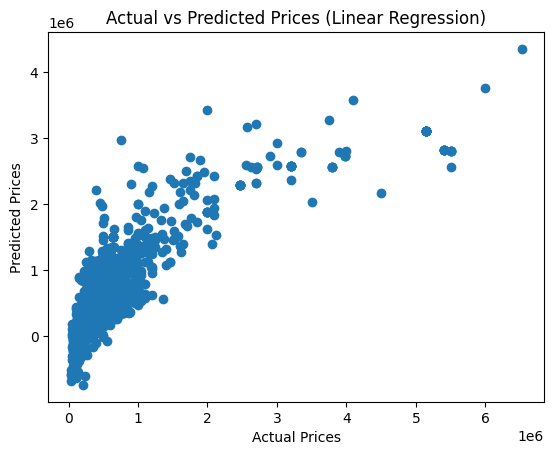

In [161]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices (Linear Regression)")

plt.show()

In [163]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [165]:
y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:10]

array([156978.5       , 565299.96      , 426874.76      , 161499.98      ,
       388425.        , 186429.52380952, 383199.95      , 534914.99166667,
       145830.        ,  69475.38333333])

In [167]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 70122.43567016895
Random Forest MSE: 20814868503.36189
Random Forest R2: 0.968245060873586


In [169]:
import pandas as pd
import matplotlib.pyplot as plt


feature_importances = rf_model.feature_importances_


importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)


print(importance_df.head(10))

                   Feature  Importance
4                max_power    0.725393
0                     year    0.192574
1                km_driven    0.024545
3                   engine    0.019811
2       mileage(km/ltr/kg)    0.018875
9   seller_type_Individual    0.006609
5                    seats    0.002944
11     transmission_Manual    0.002921
6              fuel_Diesel    0.002151
8              fuel_Petrol    0.001928


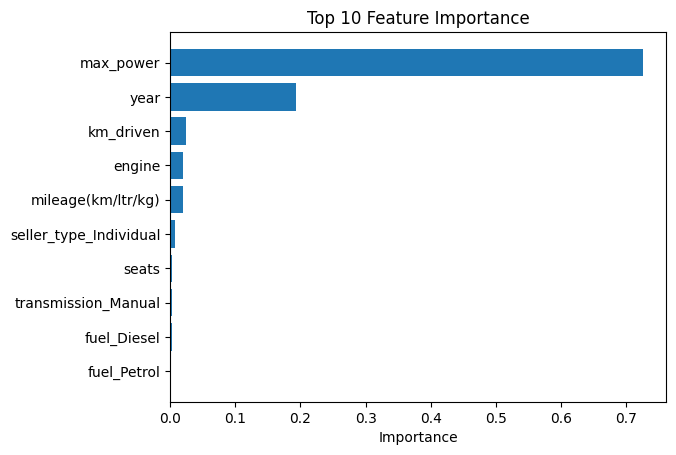

In [171]:
plt.figure()

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [174]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.94208825 0.97547527 0.96678629 0.96902967 0.9579396 ]
Average CV Score: 0.9622638153828713


In [176]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)


print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9626679946674865


In [178]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rf_model = RandomForestRegressor(
    max_depth=20,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

best_rf_model.fit(X_train, y_train)

y_pred_best = best_rf_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Tuned Random Forest MAE:", mae_best)
print("Tuned Random Forest MSE:", mse_best)
print("Tuned Random Forest R2:", r2_best)

Tuned Random Forest MAE: 70399.73595165522
Tuned Random Forest MSE: 20976238917.25389
Tuned Random Forest R2: 0.9679988759087798
